# Exploratory Data Analysis: Parfumo Fragrances

Builds on the cleaned dataset produced by `01_cleaning.ipynb` (`data/cleaned_data.parquet`). Run `01_cleaning.ipynb` first before continuing.  
Where `01_cleaning` focused on fixing structural issues, this notebook focuses on answering questions with the data.

## Table of Contents
1. [Setup](#1-setup)
2. [Analysis of Ratings and Popularity](#2-analysis-of-ratings-and-popularity)
   - [Distribution of Rating Values](#distribution-of-rating-values)
   - [Rating Count and Rating Value](#rating-count-and-rating-value)
   - [Top Brands by Average Rating](#top-brands-by-average-rating)
   - [Niche vs. Designer: Does the Gap Hold Up?](#niche-vs-designer-does-the-gap-hold-up)
3. [Closing Thoughts](#closing-thoughts)


## Summary of Findings

1. **Ratings skew high, not normal.** Values cluster around a median of ~7.4 with a left tail: most fragrances rate "good," few rate poorly, so the scale compresses at the top.

2. **Popularity and quality diverge.** More-reviewed fragrances trend toward the mean rather than the extremes. Making a widely-rated fragrance a *safe* bet, but not necessarily a *great* one.

3. **Niche brands rate higher than designer, and it's real, not a scoring artifact or a popularity effect.** Niche houses out-rate designer houses by a real, moderate margin (Cohen's d≈0.3), while designer and unclassified brands rate about the same. Strip out the ranking formula's smoothing entirely and the gap is still there. Limit the comparison to just the most-exposed, most recognizable brands in each category and it's still there. Designer brands carry roughly 3.6x more exposure than niche, which should help them if popularity were the driver, but exposure only explains about 2% of the variance in a brand's rating. *Why* (formulation strategy, who's doing the rating, price psychology, survivorship) remains an open question.


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway

# Global plot style for the whole notebook
sns.set_theme(style="whitegrid", palette="deep")

# Font fallback chain so non-Latin brand/text renders correctly
plt.rcParams['font.family'] = ['DejaVu Sans', 'Yu Gothic', 'Malgun Gothic', 'Microsoft YaHei']

df = pd.read_parquet("../data/cleaned_data.parquet")
df.shape

(59239, 16)

## 2. Analysis of Ratings and Popularity

### Distribution of Rating Values

A quick view at the overall distribution of Rating Values:  
*Are fragrance ratings distributed normally?*

Only fragrances that have a Rating Value are included, which are roughly half the fragrances in the catalog.  
For better readablity values were grouped into 0.5-point buckets. 

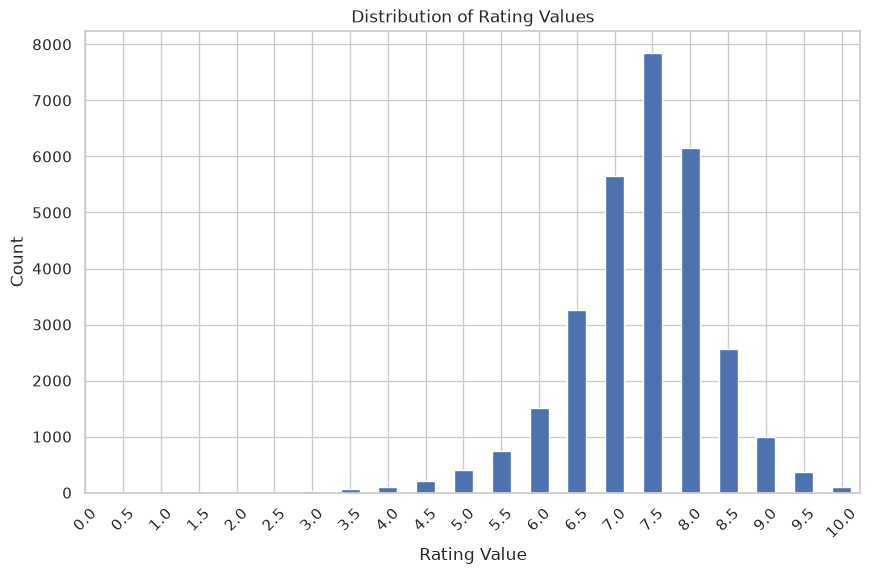

N = 30,001 fragrances with a Rating Value
Median Rating Value : 7.4


In [2]:
ratings = df['Rating_Value'].dropna()  # drop the ~half of fragrances with no rating yet


buckets = (ratings * 2).round().div(2)    # round to the nearest 0.5 so ratings can be grouped into readable buckets
full_range = pd.Series(0, index=np.arange(0, 10.5, 0.5))    # make sure all buckets are represented, even if they have 0 counts
counts = buckets.value_counts().reindex(full_range.index, fill_value=0)

ax = counts.plot(kind='bar', figsize=(10, 6));

ax.tick_params(axis='x', rotation=45)
ax.set(xlabel='Rating Value', ylabel='Count', title='Distribution of Rating Values');
ax.set_xlim(left=0)  # bars are left-skewed; drop the default half-bar margin below 0
plt.show()  


# Text below plot
print(f"N = {len(ratings):,} fragrances with a Rating Value")
print(f"Median Rating Value : {ratings.median()}")

**The data**

There's a clear single peak at 7.5, with 7.0 and 8.0 as strong neighbors: together these three buckets hold about 65% of all ~30k ratings.  
Mean = 7.35, median = 7.4, very close together, with the mean sitting slightly below the median.  
Skewness = ‑0.82, indicating a left-skewed (negatively skewed) distribution.

**The meaning**

The distribution shows that users tend to rate fragrances quite positively: the bulk of ratings sits high, with a long, thin tail stretching down toward 0.  
Very few fragrances receive a perfect 10/10, which is expected in aggregated ratings, but scores below 5.0 are similarly rare.  
As with many rating platforms, this likely reflects a bias: a fragrance rated 5.0 is probably already considered mediocre or disappointing rather than "average." This seems to shift the perceived scale, so that ratings around 7 read as "good" and around 9 as "great."

### Rating Count and Rating Value

Looking at the relationship between `Rating_Count` (popularity) and `Rating_Value` (quality):  
*Do more-reviewed fragrances rate higher, lower, or is there no relationship?*

Only fragrances with both a rating value and a rating count are considered. Again, roughly half the catalog (~29k of ~59k fragrances) has no ratings at all.   
Matplotlib silently skips these when plotting, which could hide the fact that so much of the catalog is being excluded, so they're dropped explicitly to keep the sample size and its limitations visible and intentional.

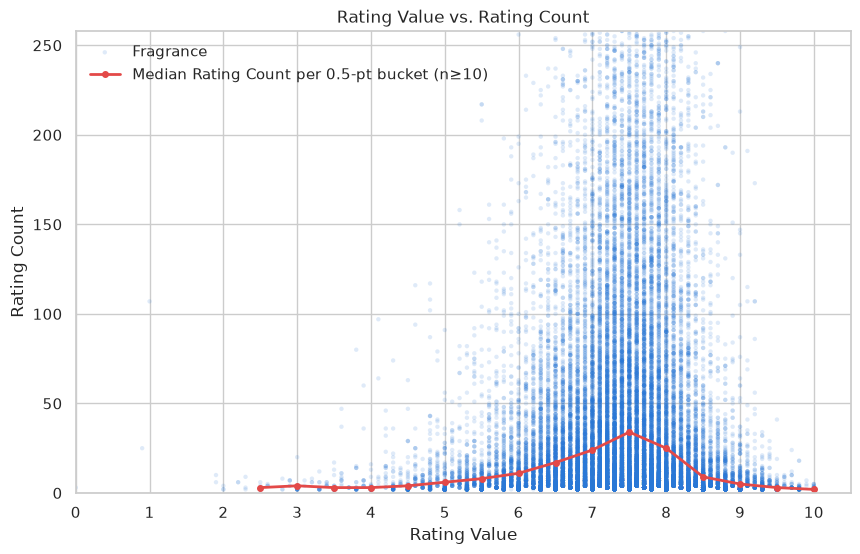

N = 30,001 fragrances with both a rating value and a rating count
Pearson r = 0.085
Spearman rho = 0.020 (p = 5.50e-04)
1496 fragrances with more than 258 ratings fall outside the y-axis above (up to 2,732 ratings) — excluded from view
Rating buckets below 2.5 were dropped from the median trend line (fewer than 10 fragrances each — too small to give a stable median)


In [3]:
rated = df.dropna(subset=["Rating_Value", "Rating_Count"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(rated["Rating_Value"], rated["Rating_Count"], s=10, alpha=0.15,
           color="#2a78d6", edgecolors="none", label="Fragrance")

# Median Rating_Count per 0.5-point rating bucket
# Buckets below Rating_Value 2.5 hold fewer than 10 fragrances each (some just 1-2),
# so their median is dominated by individual outliers -- drop those from the trend line
buckets = (rated["Rating_Value"] * 2).round().div(2)
bucket_size = buckets.value_counts()
MIN_BUCKET_N = 10
trend = rated["Rating_Count"].groupby(buckets).median()
trend = trend[bucket_size.reindex(trend.index) >= MIN_BUCKET_N]
ax.plot(trend.index, trend.values, color="#e34948", linewidth=2, marker="o",
         markersize=4, label=f"Median Rating Count per 0.5-pt bucket (n≥{MIN_BUCKET_N})")

# Zoom the y-axis to the 95th percentile so the trend line stays readable;
# a handful of very heavily-rated fragrances fall outside the visible area (noted below)
y_cap = rated["Rating_Count"].quantile(0.95)
n_excluded = int((rated["Rating_Count"] > y_cap).sum())
ax.set_ylim(0, y_cap)
ax.set_xticks(np.arange(0, 11, 1))
ax.set(xlabel="Rating Value", ylabel="Rating Count",
       title="Rating Value vs. Rating Count")
ax.set_xlim(left=0)  # ratings are left-skewed; drop the default autoscale margin below 0
ax.legend(frameon=False)
plt.show()

# Text below plot
pearson_r = rated["Rating_Value"].corr(rated["Rating_Count"])
spearman_rho, spearman_p = stats.spearmanr(rated["Rating_Value"], rated["Rating_Count"])
print(f"N = {len(rated):,} fragrances with both a rating value and a rating count")
print(f"Pearson r = {pearson_r:.3f}")
print(f"Spearman rho = {spearman_rho:.3f} (p = {spearman_p:.2e})")
print(f"{n_excluded} fragrances with more than {y_cap:.0f} ratings fall outside the y-axis above "
      f"(up to {int(rated['Rating_Count'].max()):,} ratings) — excluded from view")
print(f"Rating buckets below {trend.index.min()} were dropped from the median trend line "
      f"(fewer than {MIN_BUCKET_N} fragrances each — too small to give a stable median)")


**The data**

Pearson r ≈ 0.085 between `Rating_Value` and `Rating_Count` (r² ≈ 0.7%), meaning Rating_Value explains less than 1% of the variance in Rating_Count. A linear fit across the full range would slope upward here too (the sign follows directly from that positive r), but it's deliberately left off the chart below: at this zoom, with the y-axis capped at the 95th percentile (258 ratings) for readability, even this near-zero relationship can look like a moderate slope, and the same fit would look nearly flat against the true range (up to 2,732 ratings). Drawing it risked overstating a relationship the r² above already shows is negligible.
This zoom excludes ~1,496 fragrances (5%) from view, though they're still included in the correlation above.

Spearman ρ ≈ 0.020 (p ≈ 5×10⁻⁴) is smaller still, and statistically significant only because of the large sample size (N≈29k). Practically, it's indistinguishable from zero. Pearson (which tests for a *linear* relationship) actually reads higher here than Spearman (which tests for any *monotonic* one). That gap itself is informative: it says the weak positive Pearson slope isn't tracking a consistent monotonic trend, it's an artifact of the hump-shaped curve the median line below reveals. Neither coefficient is built to capture a hump, which is exactly why the chart is a visual help.

The red line represents the median `Rating_Count` per 0.5-point rating bucket, restricted to buckets with at least 10 fragrances. Starting around Rating_Value 2.5, it rises up to a peak around 7.0-7.5 (median ≈ 24-34 ratings), then falls back down at the high end: fragrances rated 9.5 or 10.0 have a median of only 2-3 ratings each. The relationship is hump-shaped, not linear, which is exactly why a single correlation coefficient (or a straight fit line) isn't the full picture here.

Buckets below 2.5 are deliberately excluded from this line: the 1.0 bucket, for example, contains only two fragrances (both variants of the same "Boris Becker" release) whose rating counts (107 and 25) average to a median of 66. Leaving those two data points in creates a second, misleading "hump" right at the low end of the chart.

**The meaning**

This pattern is consistent with **regression to the mean**:
With only a handful of raters, it's easy to land on an extreme average: a fragrance with 3 ratings only needs a few enthusiastic votes to average 9.5+. As the rater count grows, the average gets pulled toward the population's dominant sentiment (~7.5, the same peak seen in the rating distribution above). This is why the most-reviewed fragrances cluster in the 6.5-8.5 band rather than at the extremes.
This also explains the >1,500-rating outliers sitting in the "middle field" rather than at the top: mass popularity pulls a score toward consensus. It doesn't push a score toward perfection.

**Net takeaway:** `Rating_Count` is not a reliable proxy for quality. Heavily-rated and lightly-rated fragrances span almost the same rating range, and if anything popularity acts as a *stabilizer* against extreme scores rather than a driver of higher ones. 

### Top Brands by Average Rating

*Which brands have the highest average `Rating_Value`?*  
A simple ranking runs into an obvious problem: a brand with one fragrance rated 10/10 by two users would outrank Chanel. The usual fix is a minimum-ratings cutoff, but the check below suggests there isn't really a cutoff the data supports.

#### Is there a natural cutoff?
A minimum-ratings threshold only makes sense if reliability actually stabilizes at some point: if fragrances with 20+ ratings are safe to average while anything below that isn't. To check, fragrances were bucketed by `Rating_Count` and then looked at how much `Rating_Value` still varies within each bucket.

In [4]:
# bucket fragrances by Rating_Count, check whether Rating_Value's spread (std) stabilizes anywhere 
# that would justify a minimum-ratings cutoff
# bins start at 2, the actual minimum Rating_Count in rated (Parfumo requires 2+ ratings to publish a Rating_Value)
bins = [2, 5, 10, 15, 20, 30, 50, 100, 200, 500, rated["Rating_Count"].max() + 1]
labels = ["2-4", "5-9", "10-14", "15-19", "20-29", "30-49", "50-99", "100-199", "200-499", "500+"]
count_bucket = pd.cut(rated["Rating_Count"], bins=bins, labels=labels, right=False)
rated.groupby(count_bucket, observed=True)["Rating_Value"].agg(n="size", std="std").round(2)

,n,std
Rating_Count,,
2-4,5933,1.32
5-9,4601,1.06
10-14,2808,0.94
15-19,1994,0.85
20-29,2659,0.80
30-49,3186,0.71
50-99,3841,0.63
100-199,2792,0.58
200-499,1740,0.49


**No knee.** The spread drops off smoothly, from about 1.3 at 2-4 ratings down to 0.45 at 500+, which is just standard-error shrinking as 1/√n. This pattern does not support an emerging cutoff-point. So drawing a cutoff point would be arbitrary and not supported by data.

#### Bayesian shrinkage estimator

Rather than pick a threshold, the ranking below uses a **Bayesian shrinkage estimator**, it's the same principle behind IMDB's weighted rating:

$$WR = \frac{v}{v+m} \cdot R + \frac{m}{v+m} \cdot C$$

- `R`: the brand's own rating-count-weighted average
- `v`: the brand's exposure (total ratings across its fragrances)
- `C`: the population mean across all rated fragrances
- `m`: the shrinkage constant, the same for every brand (272), equal to the **median** number of ratings `v` across all 1,288 rated brands.

 `m` is the point where a brand's own average and the population mean get equal (50/50) weight.  
Brands with little exposure (`v` << `m`) get pulled toward `C`; brands with a lot of exposure (`v` >> `m`) keep most of their own signal `R`.

163 brands still get no score: they have zero rated fragrances, so there's nothing to average.

**Applying it to the dataset**

`C` (7.50) comes out higher than the unweighted mean reported earlier (7.35) because it weights every *rating* equally, not every *fragrance*.

The earlier mean treated a fragrance with 2 ratings and one with 2,732 ratings as one vote each, so a niche fragrance counted just as much as a mass-market one. `C` instead sums every individual rating and divides by the total count, so a fragrance with 100 ratings contributes 50x as much to `C` as one with 2 ratings. Since popular fragrances skew slightly higher-rated (r ≈ 0.085, found earlier), that extra weight pulls `C` above the flat per-fragrance average.

This shrinkage example shows the Weighted Rating in action:

```
Chanel: n=117, total_count=20294, own weighted avg=7.98 -> WR=7.97
Asabi:  n=1,   total_count=2,     own weighted avg=9.00 -> WR=7.51
```

Chanel's 20k+ ratings barely move its score, while a brand with one 2-rating fragrance gets pulled almost all the way to `C`.

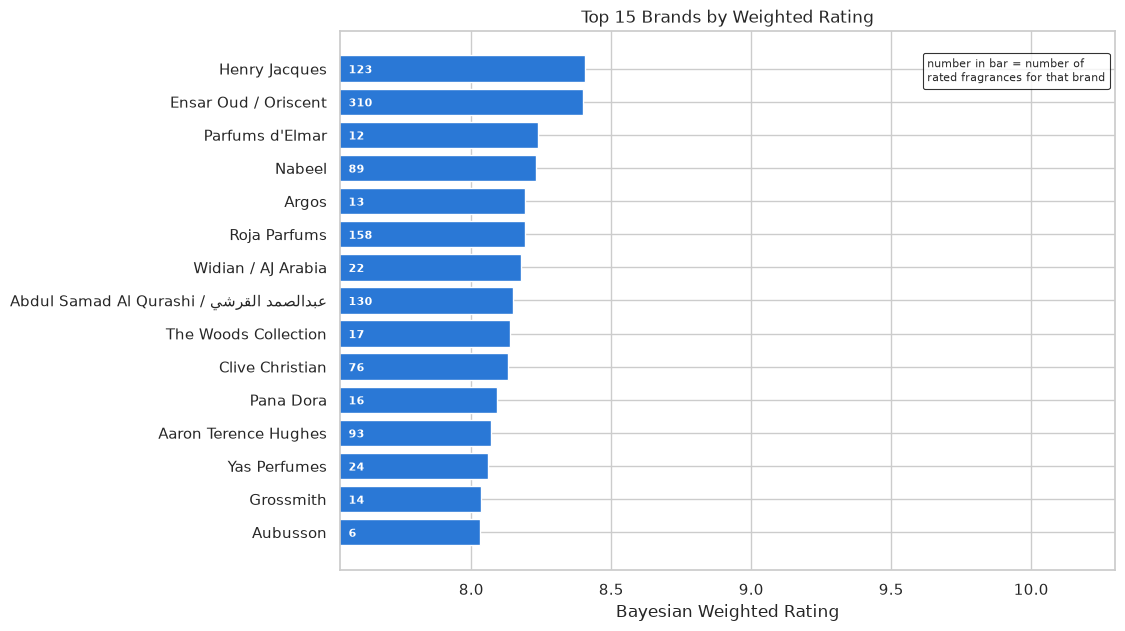

C (population mean, rating-count-weighted) = 7.50
m (shrinkage constant = median brand exposure) = 272 total ratings
1,288 of 1,451 brands get a WR score; 163 have zero rated fragrances and are absent


In [5]:
from fragrance_analysis.ratings import weighted_rating

TOP_N = 15

brand_stats = rated.groupby("Brand").agg(n=("Rating_Value", "size"), total_count=("Rating_Count", "sum"))
brand_stats["weighted_avg"] = (
    (rated["Rating_Value"] * rated["Rating_Count"]).groupby(rated["Brand"]).sum() / brand_stats["total_count"]
)

# Population mean C, and shrinkage constant m = the median brand's total exposure
# a "typical" brand gets its own signal and the population mean weighted about 50/50
# a brand with more exposure (ratings) stays mostly true to its own average
C = (rated["Rating_Value"] * rated["Rating_Count"]).sum() / rated["Rating_Count"].sum()
m = brand_stats["total_count"].median()
v = brand_stats["total_count"]
brand_stats["WR"] = weighted_rating(v=v, R=brand_stats["weighted_avg"], C=C, m=m)

top_wr = brand_stats["WR"].sort_values(ascending=False).head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_wr.index[::-1], top_wr.values[::-1], color="#2a78d6")
ax.set_xlim(top_wr.min() - 0.5, 10.3)
ax.set(xlabel="Bayesian Weighted Rating", ylabel="",
       title=f"Top {TOP_N} Brands by Weighted Rating")

# Number of rated fragrances behind each brand's WR, left-aligned inside every bar 
label_x = ax.get_xlim()[0] + 0.03
for bar, brand in zip(bars, top_wr.index[::-1]):
    n = brand_stats.loc[brand, "n"]
    ax.text(label_x, bar.get_y() + bar.get_height() / 2 - 0.05, f"{n}",
            va="center", ha="left", fontsize=8, color="white", fontweight="bold")

legend_handle = Line2D([], [], color="none")
legend = ax.legend([legend_handle],
          ["number in bar = number of\nrated fragrances for that brand"],
          bbox_to_anchor=(1,0.97), frameon=True, handlelength=0, handletextpad=0, fontsize=8)
legend.get_frame().set_facecolor("white")
legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(0.8)

plt.show()

# Text below plot
n_total_brands = df["Brand"].nunique()
n_unrated_brands = n_total_brands - len(brand_stats)
print(f"C (population mean, rating-count-weighted) = {C:.2f}")
print(f"m (shrinkage constant = median brand exposure) = {m:.0f} total ratings")
print(f"{len(brand_stats):,} of {n_total_brands:,} brands get a WR score; "
      f"{n_unrated_brands:,} have zero rated fragrances and are absent")

⚠️ **Known limitations:** Nr. 15 here (Aubusson) ranks on largely stale, discontinued-fragrance data, and The Woods Collection's low `n` is undercounted due to a scraping cap; see [`03_limitations.ipynb`](03_limitations.ipynb) §1 and §2 for details.

**The data**

Following the designer/niche split from `01_cleaning.ipynb`, all 15 brands here classify as `Niche`: a first signal that niche brands are rated more generously than designer houses.

Within the field, four brands are Gulf-owned **oud specialists** (Nabeel, Widian/AJ Arabia, Abdul Samad Al Qurashi, and Yas Perfumes), joined by Ensar Oud/Oriscent, a US-based producer with oud focus. The remaining ten split between **Western heritage/ultra-luxury** (Henry Jacques, Parfums d'Elmar, Roja Parfums, Clive Christian, Grossmith) and **small indie brands** (Argos, The Woods Collection, Pana Dora, Aaron Terence Hughes, Aubusson).

The number of rated fragrances behind each brand's score also splits cleanly in two: eight brands sit at 24 or fewer, the other seven at 76 or more, nothing in between. That split cuts across origin and style alike, so it isn't an Arabian-vs-Western divide.

**The meaning**

The complete absence of designer houses here likely traces back to the Rating Count vs. Rating Value finding: fragrances with high rating counts regress toward the population mean instead of reaching extremes. Designer fragrances tend to carry mass-market rating volumes, which caps how far their averages can stray from ~7.5. Niche fragrances, with far smaller counts, have room to land a genuinely high average. What's left at the top is a mix of low-volume traditions (Gulf oud specialists, Western ateliers, indie perfumers), none of them anywhere near designer-scale exposure.

### Niche vs. Designer: Does the Gap Hold Up?

That raises the follow-up question:  
Now that every brand is scored the same way, where do the *big* designer houses (Chanel, Dior, YSL, ...) actually land relative to niche perfumers? 

#### Remembering "designer" vs. "niche"

- **Designer / fashion house**: a brand recognized primarily from clothing, accessories, or leather goods (the kind of name on a runway or a handbag), where fragrance is a licensed line extension rather than the core business. E.g. Chanel, Dior, Yves Saint Laurent, Gucci, Prada, Hermès, Versace.
- **Niche / independent perfumery**: a brand whose entire business is fragrance, sometimes plus candles or home scents, with no clothing or leather-goods line. This covers both contemporary independent houses (Xerjoff, Amouage, Le Labo) and heritage perfumers (Guerlain, Creed) that were never fashion houses.
- **Unclassified**: everything that fits neither definition, e.g. cosmetics conglomerates, celebrity licenses, and retailers (Lancôme, Britney Spears, Bath & Body Works). Explicitly excluded rather than defaulted to niche.



#### Descriptive data

Splitting the same 1,288 rated brands by category gives a first answer to the question above: how do Designer, Niche, and Unclassified compare on average once every brand is scored the same way?

In [6]:
# category is a brand-level attribute
brand_cat_full = df.drop_duplicates("Brand").set_index("Brand")["Brand_Category"]

# restrict to brands already in brand_stats, i.e. those with at least one rated fragrance
brand_level = brand_stats.copy()
brand_level["category"] = brand_cat_full.reindex(brand_level.index)

brand_level.groupby("category").agg(n=("WR", "size"), mean_WR=("WR", "mean")).round(2)

,n,mean_WR
category,,
Designer,192,7.37
Niche,997,7.5
Unclassified,99,7.33


#### Niche houses outperform the rest, but is the difference significant?

Looking at the means, niche houses (7.5) outperform both designer (7.37) and unclassified brands (7.33).  
The question follows whether those gaps are statistically sound or just sampling noise.

A one-way ANOVA on `WR ~ category` tests whether the three group means (Designer/Niche/Unclassified) differ at all.  
Tukey's HSD then does the pairwise follow-up, with a built-in correction for testing three pairs at once, to pin down where the differences actually sit.

In [7]:
# omnibus test: does WR differ by category (Designer/Niche/Unclassified) at all?
anova_model = ols("WR ~ category", data=brand_level).fit()
display(anova_lm(anova_model, typ=2))

# pairwise follow-up (with multiple-comparison correction) to see which pairs differ
tukey = pairwise_tukeyhsd(endog=brand_level["WR"], groups=brand_level["category"], alpha=0.05)
print(tukey)

# robustness check: standard ANOVA assumes equal variance across groups, which is doubtful here
# (shrinkage compresses variance more for low-exposure brands, and group sizes are very unequal)
# Welch's ANOVA drops that assumption
welch = anova_oneway(brand_level["WR"], brand_level["category"], use_var="unequal", welch_correction=True)
print(f"\nWelch's ANOVA (unequal variances): F = {welch.statistic:.2f}, p = {welch.pvalue:.2e}")

,sum_sq,df,F,PR(>F)
category,4.687745,2.0,43.617093,4.705642e-19
Residual,69.052655,1285.0,NaN,NaN


    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1     group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------
Designer        Niche   0.1305    0.0  0.0876  0.1734   True
Designer Unclassified  -0.0365 0.4118 -0.1038  0.0308  False
   Niche Unclassified   -0.167    0.0 -0.2243 -0.1097   True
------------------------------------------------------------

Welch's ANOVA (unequal variances): F = 28.94, p = 1.03e-11


The ANOVA rejects equal means (F=43.6, p≈5×10⁻¹⁹), so the three groups differ somewhere. But category explains only about 4.69 / (4.69 + 69.05) ≈ 6% of the total variation in Weighted Ratings, so knowing whether a brand is designer or niche barely narrows down what its rating will be.

Tukey's pairwise test then shows where the difference sits: Niche differs from both Designer and Unclassified (p-adj<0.001 for both), while Designer and Unclassified are statistically indistinguishable (p-adj=0.41).

These two findings aren't in tension: the niche-vs-designer gap is a real, medium-sized effect between the group averages (Cohen's d≈0.58, niche rating higher). But the spread within each group is wide enough that the label is still a weak predictor for ratings for any single brand.

The non-result also carries its own signal. Designer and Unclassified (cosmetics conglomerates, celebrity licenses, retailers) rate about the same, which suggests the driver behind designer's lower average is licensed, mass-market positioning rather than having a clothing line specifically.

The standard ANOVA above assumes equal variance across the three groups, an assumption that's shaky here: shrinkage compresses WR's spread more for low-exposure brands, and the groups themselves are wildly unequal in size (Niche n=997 vs. Unclassified n=99). Welch's ANOVA drops that assumption and still rejects equal means (F=28.9, p≈1.0×10⁻¹¹), so the result isn't an artifact of heteroskedasticity.

#### Is the gap just an artifact of the formula?

The ranking metric (`WR`) doesn't just average a brand's own ratings. It also nudges that average toward the overall population mean, and it does so *more* the less ratings a brand has.   
Designer brands tend to have far more ratings than niche ones, so before trusting the niche-vs-designer gap, it's worth checking: is this a real pattern in how people rate fragrances, or partly a byproduct of how the score smooths things out?

To check, the same Niche-vs-Designer comparison is run on three versions of "a brand's rating," from most-processed to least:
- **`WR`**, the polished score: a brand's own average, blended with the overall average based on how many ratings it has. Built to stop a brand with two lucky 10/10 ratings from outranking a well established brand.
- **`weighted_avg`**, a brand's honest own average, with no blending toward other brands. A fragrance loved by 500 people still counts more than one rated by 2.
- **`unweighted_avg`**, the plainest number possible: the flat average across a brand's fragrances, with no weighting or smoothing at all.

In [8]:
from fragrance_analysis.ratings import cohens_d

# unweighted_avg: every fragrance counts as one vote regardless of how many people rated it
brand_level["unweighted_avg"] = rated.groupby("Brand")["Rating_Value"].mean()

# Same Niche-vs-Designer comparison run three times: 
# - WR (shrunk toward C by total_count),
# - weighted_avg (R -- rating-count-weighted but not shrunk),
# unweighted_avg (plain per-fragrance mean, no weighting or shrinkage at all)
rows = []
for metric in ["WR", "weighted_avg", "unweighted_avg"]:
    niche = brand_level.loc[brand_level["category"] == "Niche", metric]
    designer = brand_level.loc[brand_level["category"] == "Designer", metric]
    t_stat, p_val = stats.ttest_ind(niche, designer, equal_var=False)
    rows.append({
        "metric": metric,
        "niche_mean": niche.mean(),
        "designer_mean": designer.mean(),
        "mean_diff": niche.mean() - designer.mean(),
        "cohens_d": cohens_d(niche, designer),
        "t_stat": t_stat,
        "p_value": p_val,
        "n_niche": len(niche),
        "n_designer": len(designer),
    })

In [9]:
shrinkage_check = pd.DataFrame(rows).set_index("metric")
shrinkage_check["p_value"] = shrinkage_check["p_value"].map(lambda p: f"{p:.2e}")  # format before rounding, or round(4) collapses both to 0.0000
shrinkage_check = shrinkage_check.round(4)
shrinkage_check

,niche_mean,designer_mean,mean_diff,cohens_d,t_stat,p_value,n_niche,n_designer
metric,,,,,,,,
WR,7.4994,7.3688,0.1305,0.5783,5.6121,5.86e-08,997,192
weighted_avg,7.4541,7.3011,0.1530,0.2754,4.1231,4.75e-05,997,192
unweighted_avg,7.4010,7.2357,0.1653,0.2871,4.3277,2.00e-05,997,192


The gap doesn't shrink as the smoothing is stripped away. It actually grows slightly, all the way down to the plainest possible number:

| | mean gap (niche − designer) | how big it looks (Cohen's d) |
|---|---|---|
| `WR` (polished) | 0.13 | 0.58 |
| `weighted_avg` (honest, unsmoothed) | 0.15 | 0.28 |
| `unweighted_avg` (plainest) | **0.17** | 0.29 |

**So niche brands genuinely rate higher, it was not due to the choice of weighting formula.**  
What *does* change is how dramatic the gap looks statistically. `WR`'s effect size (d=0.58) reads like a solid, medium difference; the two unprocessed versions land closer to d≈0.28-0.29. That's because `WR`'s smoothing tightens the spread of scores within each group, mainly by reeling in extreme scores from tiny, low-data brands. A smaller spread makes any real gap between groups look sharper by comparison, without the underlying difference actually being any bigger. All three versions are statistically solid regardless (p from 5.9×10⁻⁸ down to 2.0×10⁻⁵). 

**Bottom line:** the niche-vs-designer gap holds up at every level of processing, including the rawest one. It is not a scoring-formula artifact. If quoting an effect size for this finding, the honest one is closer to d≈0.28-0.29 than d≈0.58: the bigger number is partly an artifact of the scoring method's smoothing, not a bigger true difference.

#### Seeing the Gap: Brand Exposure vs. Weighted Rating

The numbers say the niche-vs-designer gap is real. The plot below shows it directly: every rated brand plotted by exposure (`total_count`) against its Bayesian Weighted Rating, colored by category, with the most-exposed names in each group labeled.

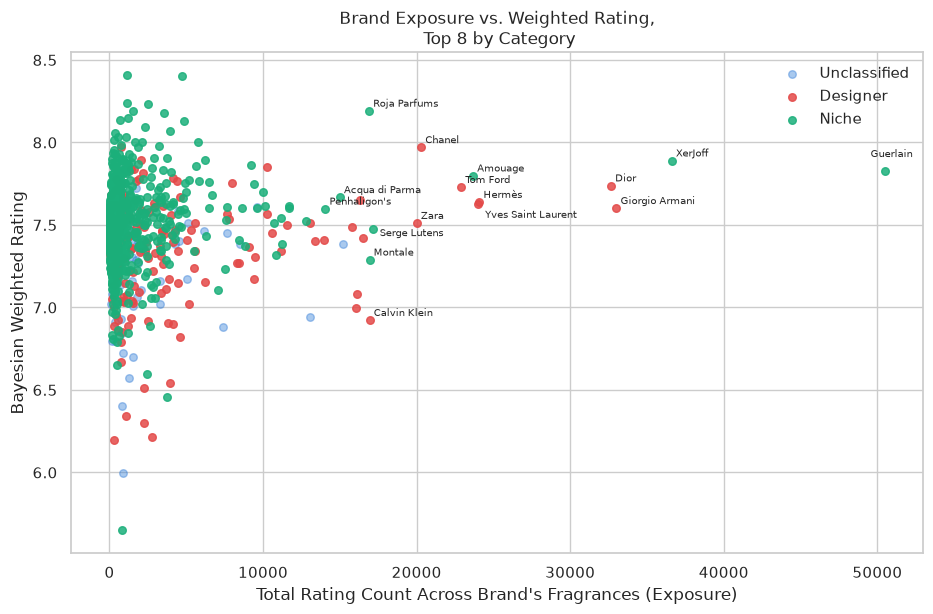

In [10]:
TOP_LABELS = 8  # label the top N by exposure within each category

top_designer = brand_level[brand_level["category"] == "Designer"].nlargest(TOP_LABELS, "total_count")
top_niche = brand_level[brand_level["category"] == "Niche"].nlargest(TOP_LABELS, "total_count")

LABEL_OFFSETS = {
     "Serge Lutens": (5, -5), "Guerlain": (-10, 10), "Yves Saint Laurent": (5, -10),
 }
# LEADER_LINES = {"Tom Ford", "Penhaligon's"}

COLORS = {"Designer": "#e34948", "Niche": "#1baf7a", "Unclassified": "#2a78d6"}

fig, ax = plt.subplots(figsize=(11, 6.5))
for cat in ["Unclassified", "Designer", "Niche"]:  # unclassified drawn first, underneath
    subset = brand_level[brand_level["category"] == cat]
    ax.scatter(subset["total_count"], subset["WR"], s=30,
               alpha=0.4 if cat == "Unclassified" else 0.85, color=COLORS[cat],
               zorder=1 if cat == "Unclassified" else 2, label=cat)

for name, row in pd.concat([top_designer, top_niche]).iterrows():
    ax.annotate(name, (row["total_count"], row["WR"]), textcoords="offset points",
                xytext=LABEL_OFFSETS.get(name, (3, 3)), fontsize=7.5)

ax.set(xlabel="Total Rating Count Across Brand's Fragrances (Exposure)", ylabel="Bayesian Weighted Rating",
       title="Brand Exposure vs. Weighted Rating,\n " \
       "Top {} by Category".format(TOP_LABELS))
ax.legend(frameon=False)
plt.show()

**The data**

Exposure and rating are positively associated but not strongly related within either category (r ≈ 0.13 for designer, r ≈ 0.16 for niche). For example, Giorgio Armani has the most designer exposure in the dataset (33k ratings), but only a 7.60 WR. 

As for the top and bottom ceilings: Designer tops out with Chanel at 7.97 (20k ratings) and Dior at 7.74 (33k ratings). Niche scores higher with Roja Parfums at 8.19 (17k ratings), Guerlain at 7.83 (50k ratings), and XerJoff at 7.89 (37k ratings). At the bottom of this same group, designer's Calvin Klein sits at 6.92, while niche's Montale sits at 7.29, more than a third of a point higher. 

A couple of dots sit even higher than Roja Parfums and aren't labeled: Henry Jacques (WR=8.41) and Ensar Oud/Oriscent (8.40), the same two brands that topped the earlier Top 15 bar chart. Both carry far less exposure than the brands labeled here (1,100 and 4,700 ratings, against 14k+ for the smallest labeled niche brand), which is why they fall outside this plot's top-8-by-exposure cutoff.

**The meaning**

The ANOVA already established that niche brands score higher on average. This plot shows the same gap holds among the specific, heavily-reviewed brands people actually recognize. It also raises an obvious question: designer brands carry far more exposure here, why doesn't that translate into higher scores?

#### If exposure is positively correlated with ratings, why don't designer brands lead?

Exposure barely predicts WR within either category (r ≈ 0.13 designer, r ≈ 0.16 niche), but the correlation is there: more exposure nudges scores up, not down. Designer brands average roughly 3.6x more total ratings per brand than niche (3,547 vs. 989), so if exposure explained the gap, designer should be ahead, not behind.

That said, exposure predicts only about 2% of the variance in WR within either category (r² ≈ 1.8% for designer, 2.5% for niche), a negligible amount. Something else is doing almost all of the work. Category itself is one candidate, but there are others worth testing directly: release year, release frequency, marketing approach, who a fragrance tends to attract as a buyer, its notes, and the associations those notes carry. Any of these could plausibly have a bigger effect than exposure's weak pull, and help explain why designer brands trail behind.

A few concrete candidates, none testable with the columns in this dataset:

- Who rates them: mass fragrances draw casual buyers with broad taste; niche fragrances draw hobbyists who already know what they like.
- Broad-appeal formulation: designer scents are often formulated to test well across a huge, undifferentiated market. That means they will be broadly *liked* without being broadly *loved equally by everyone*. That caps how high they rate. 
- Price as a rating bias: niche bottles often cost several times more. Having paid more can push a rater toward justifying that cost with a higher score, a cognitive-dissonance effect documented in wine and other luxury-good ratings.
- Survivorship: a designer house's status comes from its parent fashion brand, with guaranteed shelf space regardless of reception. A niche brand with no such backing needs to actually be good to build its following.

## Closing Thoughts

Ratings on this platform cluster high and regress toward the mean rather than the extremes, so a popular fragrance isn't necessarily a better one. Niche brands genuinely out-rate designer ones, a small but real effect that survived every check thrown at it. What isn't settled is why: exposure barely explains it, and testing the more likely candidates (formulation strategy, who's doing the rating, price psychology, survivorship) would need data this dataset doesn't have.